# Clustering Stability


This notebook will contain the first experiments on clustering stability, and understanding what it is.

In [2]:
# Main packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [4]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

We will start by fixing the aggregation level at 1 hour and the window size at 1 days. We will use 7 days of data to begin with, because of computational considerations, then will possibly extend to use large window sizes and more data. 

In [5]:
# Time
AGG_HOURS = 1
SECONDS_IN_DAY = 60 * 60 * 24
AGG_SECONDS = AGG_HOURS * 60 * 60 

### Tumbling Windows vs Sliding Windows

Justifications of using tumbling windows:
- Computationally cheaper
- Each window could be considered statistically independent
- Easier to evaluate, the metrics are easier to compare window T against window T + 1

Need to find explicit references for this.


In [ ]:
# Features dataframe
features = (
    df
    .with_columns(
        bucket=pl.col("time") // AGG_SECONDS,
        theta= ((pl.col("time") % SECONDS_IN_DAY) / SECONDS_IN_DAY) * 2 * np.pi,
        is_failure=(pl.col("outcome") != "Success").cast(pl.Int8),
    )
    .group_by(["src_user", "bucket"])
    .agg(
        n_events=pl.len(),
        failure_ratio=pl.col("is_failure").mean(),
        n_distinct_dest=pl.col("dest_comp").n_unique(),
        n_distinct_src=pl.col("src_comp").n_unique(),
        C_bar=pl.col("theta").cos().mean(),
        S_bar=pl.col("theta").sin().mean(),
    ).with_columns(
    log_n_events=pl.col("n_events").log1p(),
    log_n_distinct_dest=pl.col("n_distinct_dest").log1p(),
    log_n_distinct_src=pl.col("n_distinct_src").log1p(),
)
    .collect()
)

In [7]:
features.show(5)

src_user,bucket,n_events,failure_ratio,n_distinct_dest,n_distinct_src,C_bar,S_bar,log_n_events,log_n_distinct_dest,log_n_distinct_src
str,i64,u64,f64,u64,u64,f64,f64,f64,f64,f64
"""U1366@DOM1""",755,55,0.0,8,6,-0.996619,0.063761,4.025352,2.197225,1.94591
"""U6089@DOM1""",236,43,0.0,3,4,0.630367,-0.773081,3.78419,1.386294,1.609438
"""U2209@DOM1""",488,61,0.0,9,8,-0.581891,0.8089,4.127134,2.302585,2.197225
"""U5148@?""",1067,7,1.0,2,2,-0.992253,0.114973,2.079442,1.098612,1.098612
"""U5766@DOM1""",1201,24,0.0,4,5,0.947183,0.308368,3.218876,1.609438,1.791759


In [9]:
# Extract relevant features
feature_cols = [
    "log_n_events",
    "failure_ratio",
    "log_n_distinct_dest",
    "log_n_distinct_src",
    "C_bar",
    "S_bar",
]

### Silhoutte score to pick optimal k 

- used in sanchez paper + commonly used

In [ ]:
# Day 1
day1_features = features.filter(pl.col("bucket").is_between(0, 23))
X = day1_features.select(feature_cols).to_numpy()

In [22]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k=2  silhouette=0.3018
k=3  silhouette=0.3116
k=4  silhouette=0.3074
k=5  silhouette=0.2908
k=6  silhouette=0.2994
k=7  silhouette=0.2975
k=8  silhouette=0.2908


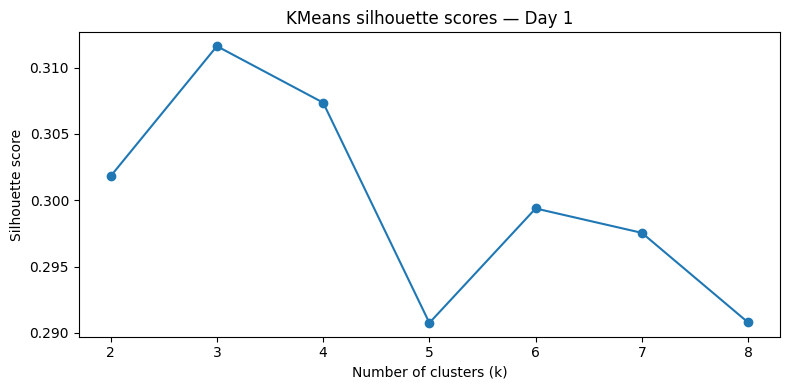

In [23]:
# KMeans sweep k=2 to 8
K_RANGE = range(2, 9)
silhouette_scores = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f"k={k}  silhouette={score:.4f}")

# %%
# Plot
plt.figure(figsize=(8, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("KMeans silhouette scores — Day 1")
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()